# E01 — le trigramme

Prédire le caractère suivant à partir des **deux** précédents.
Deux implémentations : par comptage, puis par descente de gradient.

In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
chars = sorted(list(set(''.join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}

In [3]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

## Comptage

In [4]:
N = torch.zeros((27, 27, 27), dtype=torch.int32)

for w in words:
    chrs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chrs, chrs[1:], chrs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        N[ix1, ix2, ix3] += 1

In [5]:
N.sum()

tensor(228146)

## Visualisation

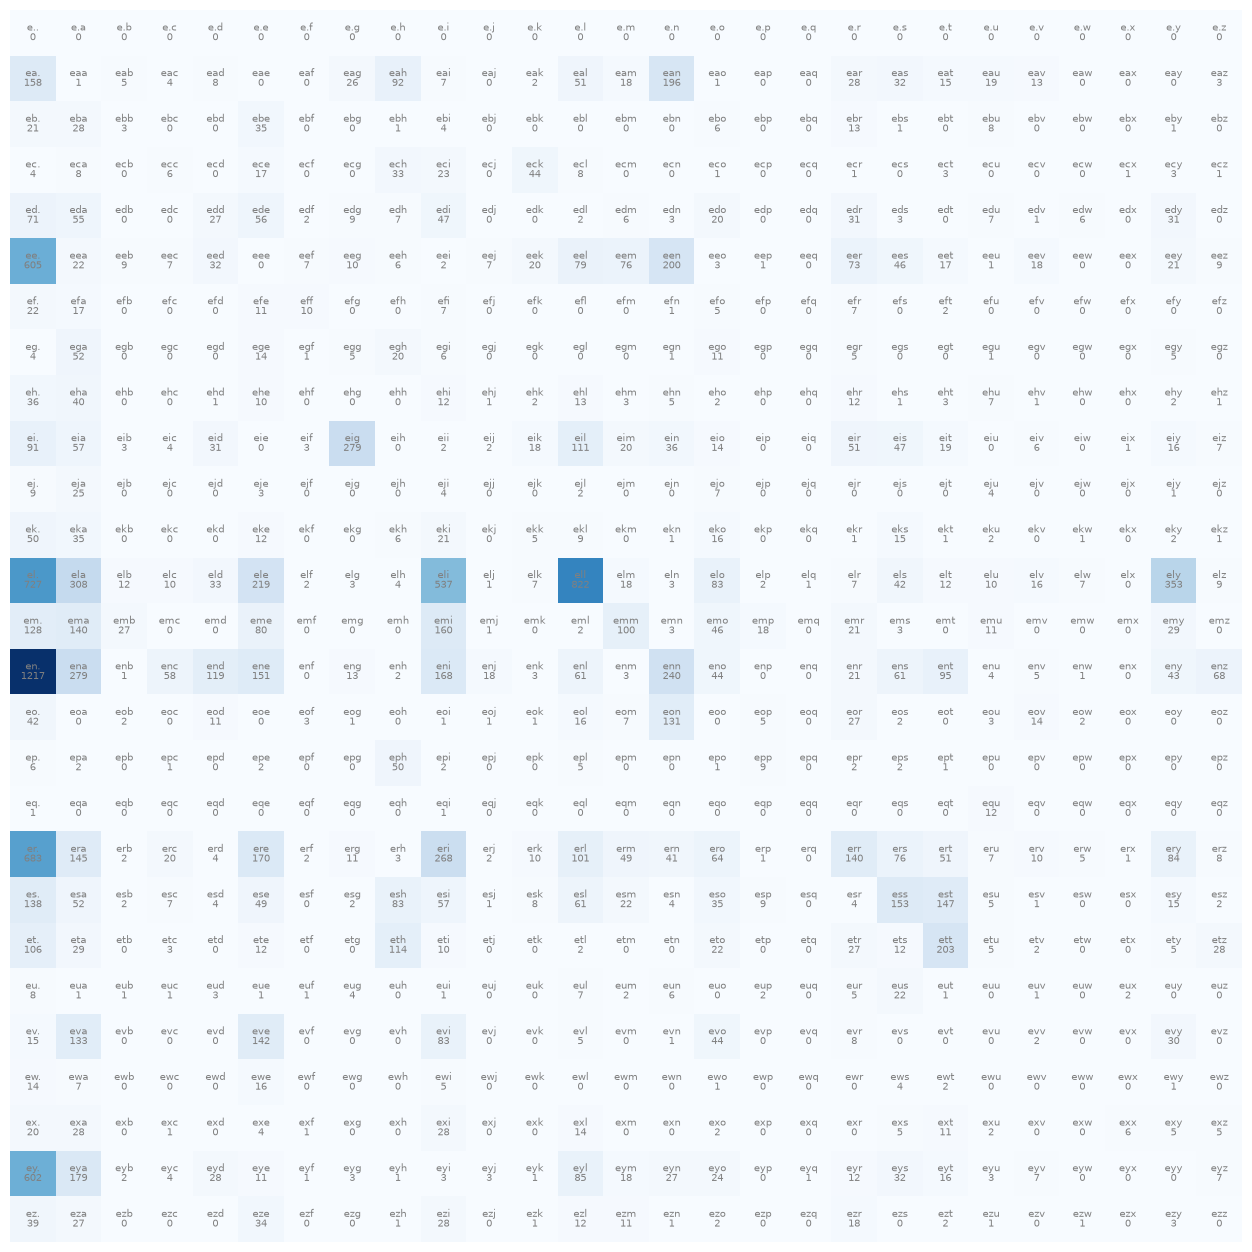

In [6]:
c = stoi['e']
plt.figure(figsize=(16,16))
plt.imshow(N[c], cmap='Blues')
for i in range(27):
    for j in range(27):
        plt.text(j, i, itos[c]+itos[i]+itos[j], ha='center', va='bottom', color='gray', fontsize=7)
        plt.text(j, i, N[c,i,j].item(), ha='center', va='top', color='gray', fontsize=7)
plt.axis('off');

## La table est creuse

C'est la mesure la plus importante de l'exercice. Elle explique pourquoi
le lissage, négligeable au bigramme, devient un vrai choix ici :
ajouter une constante à chaque cellule d'une table très creuse
déplace beaucoup de masse vers des trigrammes qui n'existent pas.

In [7]:
M = N.view(729, 27)
print('contextes jamais vus :', (M.sum(1) == 0).sum().item(), 'sur 729')
print('cellules nulles :', (M == 0).sum().item(), 'sur', M.numel())

contextes jamais vus : 127 sur 729
cellules nulles : 13620 sur 19683


## Normalisation

In [8]:
P = (N+0.01).float()
P /= P.sum(2, keepdim=True).float()

## Génération

In [9]:
g = torch.Generator().manual_seed(2147483647)

for k in range(20):
    out = []
    ix1, ix2 = 0, 0
    while True:
        p = P[ix1, ix2]
        ix3 = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix3])
        if ix3 == 0:
            break
        ix1, ix2 = ix2, ix3
    print(''.join(out))

ce.
bra.
jalius.
rochityharlonimittain.
luwak.
ka.
da.
samiyah.
javer.
gotai.
moriellavoji.
preda.
kaley.
maside.
en.
aviyah.
folspihiliven.
tahlas.
kashruban.
glen.


## Loss du modèle par comptage

In [10]:
log_likelihood = 0
n = 0

for w in words:
    chrs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chrs, chrs[1:], chrs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        prob = P[ix1, ix2, ix3]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

nll = -log_likelihood
print(f'{nll/n}')

2.1861326694488525


## Version réseau

In [11]:
xs1, xs2, ys = [], [], []
for w in words:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        xs1.append(stoi[ch1])
        xs2.append(stoi[ch2])
        ys.append(stoi[ch3])

xs = torch.tensor(xs1) * 27 + torch.tensor(xs2)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of exemples: ', num)

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((729, 27), generator=g, requires_grad=True)

number of exemples:  228146


## Entraînement

In [12]:
losses = []

for k in range (2001):
    xenc = F.one_hot(xs, num_classes=729).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(num), ys].log().mean()
    losses.append(loss.item())
    if k % 100 == 0:
        print(k, loss.item())

    W.grad = None
    loss.backward()

    W.data += -50 * W.grad

0 3.792776584625244
100 2.5085482597351074
200 2.38149356842041
300 2.3280222415924072
400 2.297999620437622
500 2.278773069381714
600 2.265404224395752
700 2.255554676055908
800 2.247979164123535
900 2.2419605255126953
1000 2.237057685852051
1100 2.2329838275909424
1200 2.229543685913086
1300 2.22659969329834
1400 2.224050283432007
1500 2.221820831298828
1600 2.2198538780212402
1700 2.218104362487793
1800 2.2165372371673584
1900 2.2151248455047607
2000 2.2138445377349854


In [13]:
g = torch.Generator().manual_seed(2147483647)

for k in range(20):
    out = []
    ix1, ix2 = 0, 0
    while True:
        ctx = ix1 * 27 + ix2
        xenc = F.one_hot(torch.tensor([ctx]), num_classes=729).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)
        ix3 = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix3])
        if ix3 == 0:
            break
        ix1, ix2 = ix2, ix3
    print(''.join(out))


ce.
bra.
jalius.
rochityharlonimittain.
luwan.
ka.
da.
samiyah.
javer.
gotai.
moriellavorie.
teda.
kaley.
maside.
en.
aviony.
fobspihaniven.
tahlas.
kashrxdleenlen.
al.
